In [1]:
import numpy as np
import glob, os, sys
import copy
import xarray as xr
import pandas as pd
from scipy.ndimage import label, binary_dilation, binary_erosion, generate_binary_structure
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
# For non-gui matplotlib back end
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
mpl.use('agg')
import dask
from dask.distributed import Client, LocalCluster
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
# from pyflextrkr.ft_utilities import load_config, subset_files_timerange

In [2]:
#-----------------------------------------------------------------------
def label_perimeter(tracknumber, dilationstructure):
    """
    Labels the perimeter on a 2D map from object tracknumber masks.
    """
    # Get unique tracknumbers that is no nan
    tracknumber_unique = np.unique(tracknumber[~np.isnan(tracknumber)]).astype(np.int32)

    # Make an array to store the perimeter
    tracknumber_perim = np.zeros(tracknumber.shape, dtype=np.int32)

    # Loop over each tracknumbers
    for ii in tracknumber_unique:
        # Isolate the cell mask
        itn = tracknumber == ii
        # Erode the cell by 1 pixel
        itn_erode = binary_erosion(itn, structure=dilationstructure).astype(itn.dtype)
        # Subtract the eroded area to get the perimeter
        iperim = np.logical_xor(itn, itn_erode)
        # Label the perimeter pixels with the track number
        tracknumber_perim[iperim == 1] = ii

    return tracknumber_perim

#-----------------------------------------------------------------------
def calc_cell_center(tracknumber, longitude, latitude, xx, yy):
    """
    Calculates the center location from labeled cells.
    """
    
    # Find unique tracknumbers
    tracknumber_uniqe = np.unique(tracknumber[~np.isnan(tracknumber)])
    num_tracknumber = len(tracknumber_uniqe)
    # Make arrays for cell center locations
    lon_c = np.full(num_tracknumber, np.nan, dtype=float)
    lat_c = np.full(num_tracknumber, np.nan, dtype=float)
    xx_c = np.full(num_tracknumber, np.nan, dtype=float)
    yy_c = np.full(num_tracknumber, np.nan, dtype=float)

    # Loop over each tracknumbers to calculate the mean lat/lon & x/y for their center locations
    for ii, itn in enumerate(tracknumber_uniqe):
        iyy, ixx = np.where(tracknumber == itn)
        # lon_c[ii] = np.mean(longitude[iyy, ixx])
        # lat_c[ii] = np.mean(latitude[iyy, ixx])
        lon_c[ii] = np.mean(longitude[tracknumber == itn])
        lat_c[ii] = np.mean(latitude[tracknumber == itn])
        xx_c[ii] = np.mean(xx[ixx])
        yy_c[ii] = np.mean(yy[iyy])
        
    return lon_c, lat_c, xx_c, yy_c, tracknumber_uniqe

#-----------------------------------------------------------------------
def calc_latlon(lon1, lat1, dist, angle):
    """
    Haversine formula to calculate lat/lon locations from distance and angle.
    
    lon1:   longitude in [degree]
    lat1:   latitude in [degree]
    dist:   distance in [km]
    angle:  angle in [degree]
    """

    import math

    # Earth radius
    # R_earth = 6378.39  # at Equator [km]
    R_earth = 6374.2  # at 40 degree latitude [km]
#     R_earth = 6356.91  # at the pole [km]

    # Conver degrees to radians
    lat1 = math.radians(lat1)
    lon1 = math.radians(lon1)
    bearing = math.radians(angle)

    lat2 = math.asin(math.sin(lat1) * math.cos(dist/R_earth) +
                     math.cos(lat1) * math.sin(dist/R_earth) * math.cos(bearing))
    lon2 = lon1 + math.atan2(math.sin(bearing) * math.sin(dist/R_earth) * math.cos(lat1),
                             math.cos(dist/R_earth) - math.sin(lat1) * math.sin(lat2))
    lat2 = math.degrees(lat2)
    lon2 = math.degrees(lon2)

    return lon2, lat2

#-----------------------------------------------------------------------
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """ 
    Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap


In [3]:
# Set subset map domain
# map_extend = [-65.4, -63.2, -33.2, -30.8]
# # Set lat/lon labels
# lon_bin = 1
# lat_bin = 1
# lonv = np.arange(-65.4, -63.1, 1)
# latv = np.arange(-33, -31.1, 1)
# Set subset map domain
map_extend = [-65.9, -63.6, -33.1, -31.15]
# Set lat/lon labels
lon_bin = 1
lat_bin = 1
lonv = np.arange(-65, -63.01, 1)
latv = np.arange(-33, -31.01, 1)
# Put map info in a dictionary
map_info = {
    'map_extend': map_extend,
    'lonv': lonv,
    'latv': latv,
}

# vec_subsample = 45  # Sample vector field every N points: 7, 15, 45, & 100 work well for domains 1-4, respectively
# vec_scale = 55  # Scale parameter for setting vector length
vec_subsample = 25  # Sample vector field every N points: 7, 15, 45, & 100 work well for domains 1-4, respectively
vec_scale_up = 80  # Scale parameter for setting vector length
vec_scale_low = 30


# Get directory info from config file
# config = load_config(config_file)
# pixeltracking_path = config["tracking_outpath"]
# pixeltracking_filebase = config["cloudid_filebase"]
# n_workers = config["nprocesses"]
pixeltracking_path = '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les/20181204_gefs_en18/500m/celltracking/20181204.1200_20181205.0000/'
pixeltracking_filebase = "celltracks_"
regrid_path = '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les/20181204/gefs18/run/merged/'
regrid_filebase = 'corlasso_sub_metOnHamsl.M1.m1.gefs18_'
map_file = '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les/map_data/corlasso_sub_static.M1.m1.gefs18_2018120400_f120000_d3.nc'
n_workers = 1

# Output figure directory
figdir = f'{pixeltracking_path}/quicklooks/'
os.makedirs(figdir, exist_ok=True)
print(figdir)

/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les/20181204_gefs_en18/500m/celltracking/20181204.1200_20181205.0000//quicklooks/


In [4]:
# datafiles

start_datetime = '2018-12-04T20:00'
end_datetime = '2018-12-04T20:05'

# Generate time marks within the start/end datetime
file_datetimes = pd.date_range(start=start_datetime, end=end_datetime, freq='15min').strftime('%Y%m%d_%H%M')
met_datetimes = pd.date_range(start=start_datetime, end=end_datetime, freq='15min').strftime('%Y%m%d00_f%H%M')

datafiles = []
metfiles = []
for tt in range(0, len(file_datetimes)):
    datafiles.extend(sorted(glob.glob(f'{pixeltracking_path}{pixeltracking_filebase}{file_datetimes[tt]}*')))
    metfiles.extend(sorted(glob.glob(f'{regrid_path}{regrid_filebase}{met_datetimes[tt]}*')))
print(f'Number of pixel files: {len(datafiles)}')
print(f'Number of met files: {len(metfiles)}')

Number of pixel files: 1
Number of met files: 1


In [5]:
metfiles

['/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les/20181204/gefs18/run/merged/corlasso_sub_metOnHamsl.M1.m1.gefs18_2018120400_f200000_d3.nc']

In [6]:
dsmap = xr.open_dataset(map_file)
dsmap

<xarray.Dataset>
Dimensions:    (Time: 1, bottom_top: 149, bottom_top_stag: 150,
                soil_layers_stag: 4, south_north: 865, west_east: 750,
                west_east_stag: 751, south_north_stag: 866)
Coordinates:
  * Time       (Time) datetime64[ns] 2018-12-04T12:00:00
    XLONG      (south_north, west_east) float32 ...
    XLAT       (south_north, west_east) float32 ...
    XTIME      (Time) float32 ...
Dimensions without coordinates: bottom_top, bottom_top_stag, soil_layers_stag,
                                south_north, west_east, west_east_stag,
                                south_north_stag
Data variables: (12/47)
    ITIMESTEP  (Time) int32 ...
    ZNU        (Time, bottom_top) float32 ...
    ZNW        (Time, bottom_top_stag) float32 ...
    ZS         (Time, soil_layers_stag) float32 ...
    DZS        (Time, soil_layers_stag) float32 ...
    HGT        (Time, south_north, west_east) float32 ...
    ...         ...
    SINALPHA   (Time, south_north, west_east) float32 ...
    COSALPHA   (Time, south_north, west_east) float32 ...
    XLAT_U     (Time, south_north, west_east_stag) float32 ...
    XLONG_U    (Time, south_north, west_east_stag) float32 ...
    XLAT_V     (Time, south_north_stag, west_east) float32 ...
    XLONG_V    (Time, south_north_stag, west_east) float32 ...
Attributes: (12/37)
    DX:                          500.0
    DY:                          500.0
    SIMULATION_START_DATE:       2018-12-04_06:00:00
    WEST-EAST_GRID_DIMENSION:    751
    SOUTH-NORTH_GRID_DIMENSION:  866
    BOTTOM-TOP_GRID_DIMENSION:   150
    ...                          ...
    location_description:        Cloud, Aerosol, and Complex Terrain Interact...
    data_level:                  m1
    datastream:                  corlasso_sub_static
    contact:                     lasso@arm.gov, LASSO PI: William Gustafson (...
    doi:                         https://doi.org/10.5439/????
    history:                     processed by user zhe1feng1 on machine cirru...

In [7]:
datafile = datafiles[0]
metfile = metfiles[0]

# Read data file
ds = xr.open_dataset(datafile)
# Make x,y coordinates
ds.coords['lon'] = ds.lon
ds.coords['lat'] = ds.lat
xx = ds.lon.data
yy = ds.lat.data
longitude = ds.longitude.data
latitude = ds.latitude.data

In [8]:
dsm = xr.open_dataset(metfile)
dsm = dsm.rename_dims({'south_north':'lat', 'west_east':'lon'})
dsm

<xarray.Dataset>
Dimensions:      (Time: 1, lat: 865, lon: 750, HAMSL: 29)
Coordinates:
  * Time         (Time) datetime64[ns] 2018-12-04T20:00:00
    XLONG        (lat, lon) float32 ...
    XLAT         (lat, lon) float32 ...
    XTIME        (Time) float32 ...
  * HAMSL        (HAMSL) float64 500.0 1e+03 1.5e+03 ... 1.9e+04 2e+04 2.1e+04
Dimensions without coordinates: lat, lon
Data variables: (12/34)
    ITIMESTEP    (Time) int32 ...
    HGT          (Time, lat, lon) float32 ...
    MUTOT        (Time, lat, lon) float32 ...
    PRESSURE     (Time, HAMSL, lat, lon) float32 ...
    ALT          (Time, HAMSL, lat, lon) float32 ...
    TEMPERATURE  (Time, HAMSL, lat, lon) float32 ...
    ...           ...
    LCL          (Time, lat, lon) float32 ...
    LFC          (Time, lat, lon) float32 ...
    LNB          (Time, lat, lon) float32 ...
    LPL          (Time, lat, lon) float32 ...
    MUCAPE       (Time, lat, lon) float32 ...
    MUCIN        (Time, lat, lon) float32 ...
Attributes: (12/37)
    DX:                          500.0
    DY:                          500.0
    SIMULATION_START_DATE:       2018-12-04_06:00:00
    WEST-EAST_GRID_DIMENSION:    751
    SOUTH-NORTH_GRID_DIMENSION:  866
    BOTTOM-TOP_GRID_DIMENSION:   150
    ...                          ...
    location_description:        Cloud, Aerosol, and Complex Terrain Interact...
    data_level:                  m1
    datastream:                  corlasso_sub_metOnHamsl
    contact:                     lasso@arm.gov, LASSO PI: William Gustafson (...
    doi:                         https://doi.org/10.5439/????
    history:                     processed by user zhe1feng1 on machine cirru...

In [15]:
#-----------------------------------------------------------------------
def plot_map_4panels(pixel_dict, plot_info, map_info):
    """
    Plot with Cartopy map projection.
    """

    # Get pixel data from dictionary
    xx = pixel_dict['longitude']
    yy = pixel_dict['latitude']
    xx_s = pixel_dict['lon_subsample']
    yy_s = pixel_dict['lat_subsample']
    terrain = pixel_dict['terrain']
    comp_ref = pixel_dict['comp_ref']
    lowlevel_ref = pixel_dict['lowlevel_ref']
    conv_mask = pixel_dict['conv_mask']
    tn = pixel_dict['tn']
    tn_perim = pixel_dict['tn_perim']
    notn_perim = pixel_dict['cn_notrack_perim']
    xx_tn = pixel_dict['lon_tn1']
    yy_tn = pixel_dict['lat_tn1']
    tracknumbers = pixel_dict['tnconv1_unique'] 
    xx_cn = pixel_dict['lon_cn1']
    yy_cn = pixel_dict['lat_cn1']
    notracknumbers = pixel_dict['cnnotrack_unique']
    u_low = pixel_dict['u_low']
    v_low = pixel_dict['v_low']
    w_low = pixel_dict['w_low']
    u_up = pixel_dict['u_up']
    v_up = pixel_dict['v_up']
    w_up = pixel_dict['w_up']
    # Get plot info from dictionary
    levels_ref = plot_info['levels_ref']
    levels_w_low = plot_info['levels_w_low']
    levels_w_up = plot_info['levels_w_up']
    cmap_ref = plot_info['cmap_ref']
    cmap_w = plot_info['cmap_w']
    titles = plot_info['titles'] 
    cblabel_ref = plot_info['cblabel_ref']
    cbticks_ref = plot_info['cbticks_ref']
    cblabel_w_up = plot_info['cblabel_w_up']
    cblabel_w_low = plot_info['cblabel_w_low']
    cbticks_w_up = plot_info['cbticks_w_up']
    cbticks_w_low = plot_info['cbticks_w_low']
    timestr = plot_info['timestr']
    figname = plot_info['figname']
    # Map domain, lat/lon ticks, background map features
    map_extend = map_info['map_extend']
    lonv = map_info['lonv']
    latv = map_info['latv']

    perim_color = 'k'

    radii = np.arange(20,101,20)  # radii for the range rings [km]
    # azimuths = np.arange(0,361,30)  # azimuth angles for HSRHI scans [degree]
    azimuths = np.arange(0,361,90)
    radar_lon, radar_lat = -64.7284, -32.1264  # CSAPR radar location
    levels_hgt = np.arange(1000, 2500.1, 500)
    
    proj = ccrs.PlateCarree()
    
    mpl.rcParams['font.size'] = 11
    mpl.rcParams['font.family'] = 'Helvetica'
    # fig = plt.figure(figsize=[11,9.2], dpi=200, facecolor='w')
    fig = plt.figure(figsize=[12,10], dpi=200, facecolor='w')
    
    # Set up the two panels with GridSpec, use GridSpecFromSubplotSpec to make enough space between the two panels for colorbars
    # and make the colorbars right next to the panels
    # This may be overkill to use GridSpec but it's a good example to have complete control of the locations, 
    # which is good for making animations where the panel locations need to be locked
    # Set GridSpec for left and right panel
    gs = gridspec.GridSpec(1,2, height_ratios=[1], width_ratios=[0.5,0.5])
    gs.update(left=0.05, right=0.94, top=0.92, bottom=0.05, wspace=0.35, hspace=0.1)
    # Use GridSpecFromSubplotSpec for panel and colorbar
    gs_left = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0], height_ratios=[0.5,0.5], width_ratios=[0.5,0.02], wspace=0.05, hspace=0.15)
    gs_right = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[1], height_ratios=[0.5,0.5], width_ratios=[0.5,0.02], wspace=0.05, hspace=0.15)
    
    fig.text(0.5, 0.95, timestr, fontsize=14, ha='center')
    
    ##########################################################
    # Panel 1
    ##########################################################
    ax1 = plt.subplot(gs_left[0,0], projection=proj)
    ax1.set_extent(map_extend, crs=proj)
    ax1.set_aspect('auto', adjustable=None)
    gl = ax1.gridlines(crs=proj, draw_labels=False, linestyle='--', linewidth=0.)
    gl.xlocator = mpl.ticker.FixedLocator(lonv)
    gl.ylocator = mpl.ticker.FixedLocator(latv)
    ax1.set_xticks(lonv, crs=proj)
    ax1.set_yticks(latv, crs=proj)
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()        
    ax1.xaxis.set_major_formatter(lon_formatter)
    ax1.yaxis.set_major_formatter(lat_formatter)
    ax1.set_title(titles[0], loc='left')
    
    # Plot reflectivity
    cmap = plt.get_cmap(cmap_ref)
    norm_ref = mpl.colors.BoundaryNorm(levels_ref, ncolors=cmap.N, clip=True)
    comp_ref = np.ma.masked_where(comp_ref < min(levels_ref), comp_ref)
    cf1 = ax1.pcolormesh(xx, yy, comp_ref, shading='nearest', norm=norm_ref, cmap=cmap_ref, transform=proj, zorder=2)
    # Reflectivity colorbar
    cax1 = plt.subplot(gs_left[0,1])
    cb1 = plt.colorbar(cf1, cax=cax1, label=cblabel_ref, ticks=cbticks_ref, extend='both')
    # Plot cell tracknumber perimeters
    Tn = np.ma.masked_where(tn_perim == 0, tn_perim)
    Tn[Tn > 0] = 10
    tn1 = ax1.pcolormesh(xx, yy, Tn, shading='nearest', cmap='gray', transform=proj, alpha=1, zorder=4)

    # Overplot cell tracknumbers
    for ii in range(0, len(xx_tn)):
        ax1.text(xx_tn[ii], yy_tn[ii], f'{tracknumbers[ii]:.0f}', color='k', size=10, weight='bold', ha='left', va='center', transform=proj, zorder=4)

    # Plot range circles around radar
    for ii in range(0, len(radii)):
        rr = ax1.tissot(rad_km=radii[ii], lons=radar_lon, lats=radar_lat, n_samples=100, facecolor='None', edgecolor='k', lw=0.4, zorder=3)
    # Plot azimuth lines
    for ii in range(0, len(azimuths)):
        lon2, lat2 = calc_latlon(radar_lon, radar_lat, 200, azimuths[ii])
        ax1.plot([radar_lon,lon2], [radar_lat,lat2], color='k', lw=0.4, transform=ccrs.Geodetic(), zorder=5)
    
    # # Plot terrain
    # ct1 = ax1.contour(xx, yy, terrain, levels=levels_hgt, colors='dimgray', lw=0.5, transform=proj, zorder=3)
    # Plot AMF site
    ax1.plot(radar_lon, radar_lat, color='r', marker='*', markersize=8, zorder=10)
    ax1.plot(radar_lon, radar_lat, color='k', marker='*', markersize=8, fillstyle='none', zorder=10)
    # # ax1.text(radar_lon, radar_lat-0.1, 'AMF', color='k', fontsize=16, fontweight='bold', zorder=10)
    
    
    ##########################################################
    # Panel 2
    ##########################################################
    ax2 = plt.subplot(gs_right[0,0], projection=proj)
    ax2.set_extent(map_extend, crs=proj)
    ax2.set_aspect('auto', adjustable=None)
    gl = ax2.gridlines(crs=proj, draw_labels=False, linestyle='--', linewidth=0.)
    gl.xlocator = mpl.ticker.FixedLocator(lonv)
    gl.ylocator = mpl.ticker.FixedLocator(latv)
    ax2.set_xticks(lonv, crs=proj)
    ax2.set_yticks(latv, crs=proj)
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    ax2.xaxis.set_major_formatter(lon_formatter)
    ax2.yaxis.set_major_formatter(lat_formatter)
    ax2.set_title(titles[1], loc='left')
    
    # Plot reflectivity
    lowlevel_ref = np.ma.masked_where(lowlevel_ref < min(levels_ref), lowlevel_ref)
    cf2 = ax2.pcolormesh(xx, yy, lowlevel_ref, shading='nearest', norm=norm_ref, cmap=cmap_ref, transform=proj, zorder=2)
    # Reflectivity colorbar
    cax2 = plt.subplot(gs_right[0,1])
    cb2 = plt.colorbar(cf2, cax=cax2, label=cblabel_ref, ticks=cbticks_ref, extend='both')
    # Plot cell tracknumber perimeters
    tn2 = ax2.pcolormesh(xx, yy, Tn, shading='nearest', cmap='gray', transform=proj, alpha=1, zorder=4)
    # Plot AMF site
    ax2.plot(radar_lon, radar_lat, color='r', marker='*', markersize=8, zorder=10)
    ax2.plot(radar_lon, radar_lat, color='k', marker='*', markersize=8, fillstyle='none', zorder=10)
    
    ##########################################################
    # Panel 3
    ##########################################################
    ax3 = plt.subplot(gs_left[1,0], projection=proj)
    ax3.set_extent(map_extend, crs=proj)
    ax3.set_aspect('auto', adjustable=None)
    gl = ax3.gridlines(crs=proj, draw_labels=False, linestyle='--', linewidth=0.)
    gl.xlocator = mpl.ticker.FixedLocator(lonv)
    gl.ylocator = mpl.ticker.FixedLocator(latv)
    ax3.set_xticks(lonv, crs=proj)
    ax3.set_yticks(latv, crs=proj)
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    ax3.xaxis.set_major_formatter(lon_formatter)
    ax3.yaxis.set_major_formatter(lat_formatter)
    ax3.set_title(titles[2], loc='left')
    
    # Plot W
    cmap = plt.get_cmap(cmap_w)
    norm_w = mpl.colors.BoundaryNorm(levels_w_up, ncolors=cmap.N, clip=True)
    w_up = np.ma.masked_where(w_up < min(levels_w_up), w_up)
    cf3 = ax3.pcolormesh(xx, yy, w_up, shading='nearest', norm=norm_w, cmap=cmap_w, transform=proj, zorder=2)
    # W colorbar
    cax3 = plt.subplot(gs_left[1,1])
    cb3 = plt.colorbar(cf3, cax=cax3, label=cblabel_w_up, ticks=cbticks_w_up, extend='both')
    # Plot cell tracknumber perimeters
    tn3 = ax3.pcolormesh(xx, yy, Tn, shading='nearest', cmap='gray', transform=proj, alpha=0.7, zorder=4)
    # Overlay the wind vectors
    qvr3 = ax3.quiver(xx_s, yy_s, u_up.data, v_up.data, units='inches', angles='xy', scale=vec_scale_up, scale_units="inches", color='k', transform=proj, zorder=4)
    qvrk3 = ax3.quiverkey(qvr3, 1.05, -0.05, 10, '10 m/s', labelpos='E', coordinates='axes')
    # Plot AMF site
    ax3.plot(radar_lon, radar_lat, color='r', marker='*', markersize=8, zorder=10)
    ax3.plot(radar_lon, radar_lat, color='k', marker='*', markersize=8, fillstyle='none', zorder=10)
    
    ##########################################################
    # Panel 4
    ##########################################################
    ax4 = plt.subplot(gs_right[1,0], projection=proj)
    ax4.set_extent(map_extend, crs=proj)
    ax4.set_aspect('auto', adjustable=None)
    gl = ax4.gridlines(crs=proj, draw_labels=False, linestyle='--', linewidth=0.)
    gl.xlocator = mpl.ticker.FixedLocator(lonv)
    gl.ylocator = mpl.ticker.FixedLocator(latv)
    ax4.set_xticks(lonv, crs=proj)
    ax4.set_yticks(latv, crs=proj)
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    ax4.xaxis.set_major_formatter(lon_formatter)
    ax4.yaxis.set_major_formatter(lat_formatter)
    ax4.set_title(titles[3], loc='left')
    
    # Plot W
    cmap = plt.get_cmap(cmap_w)
    norm_w = mpl.colors.BoundaryNorm(levels_w_low, ncolors=cmap.N, clip=True)
    w_low = np.ma.masked_where(w_low < min(levels_w_low), w_low)
    cf4 = ax4.pcolormesh(xx, yy, w_low, shading='nearest', norm=norm_w, cmap=cmap_w, transform=proj, zorder=2)
    # W colorbar
    cax4 = plt.subplot(gs_right[1,1])
    cb4 = plt.colorbar(cf4, cax=cax4, label=cblabel_w_low, ticks=cbticks_w_low, extend='both')
    # Plot cell tracknumber perimeters
    tn4 = ax4.pcolormesh(xx, yy, Tn, shading='nearest', cmap='gray', transform=proj, alpha=0.7, zorder=4) 
    # Overlay the wind vectors
    qvr4 = ax4.quiver(xx_s, yy_s, u_low.data, v_low.data, units='inches', angles='xy', scale=vec_scale_low, scale_units="inches", color='k', transform=proj, zorder=4)
    qvrk4 = ax4.quiverkey(qvr4, 1.05, -0.05, 5, '5 m/s', labelpos='E', coordinates='axes')
    # Plot terrain
    ct4 = ax4.contour(xx, yy, terrain, levels=levels_hgt, colors='dimgray', linewidths=0.7, transform=proj, zorder=3)
    # Plot AMF site
    ax4.plot(radar_lon, radar_lat, color='r', marker='*', markersize=8, zorder=10)
    ax4.plot(radar_lon, radar_lat, color='k', marker='*', markersize=8, fillstyle='none', zorder=10)
    
    # fig.savefig(figname, dpi=200, facecolor='w', bbox_inches='tight')
    # Thread-safe figure output
    canvas = FigureCanvas(fig)
    canvas.print_png(figname)
    fig.savefig(figname)
    return fig

In [16]:
perim_thick = 5
dilationstructure = np.zeros((perim_thick+1,perim_thick+1), dtype=int)
dilationstructure[1:perim_thick, 1:perim_thick] = 1
dilationstructure

array([[0, 0, 0, 0, 0, 0],
       [0, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 1, 0],
       [0, 0, 0, 0, 0, 0]])

/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les/20181204_gefs_en18/500m/celltracking/20181204.1200_20181205.0000//quicklooks/celltrack_winds_20181204_2000.png


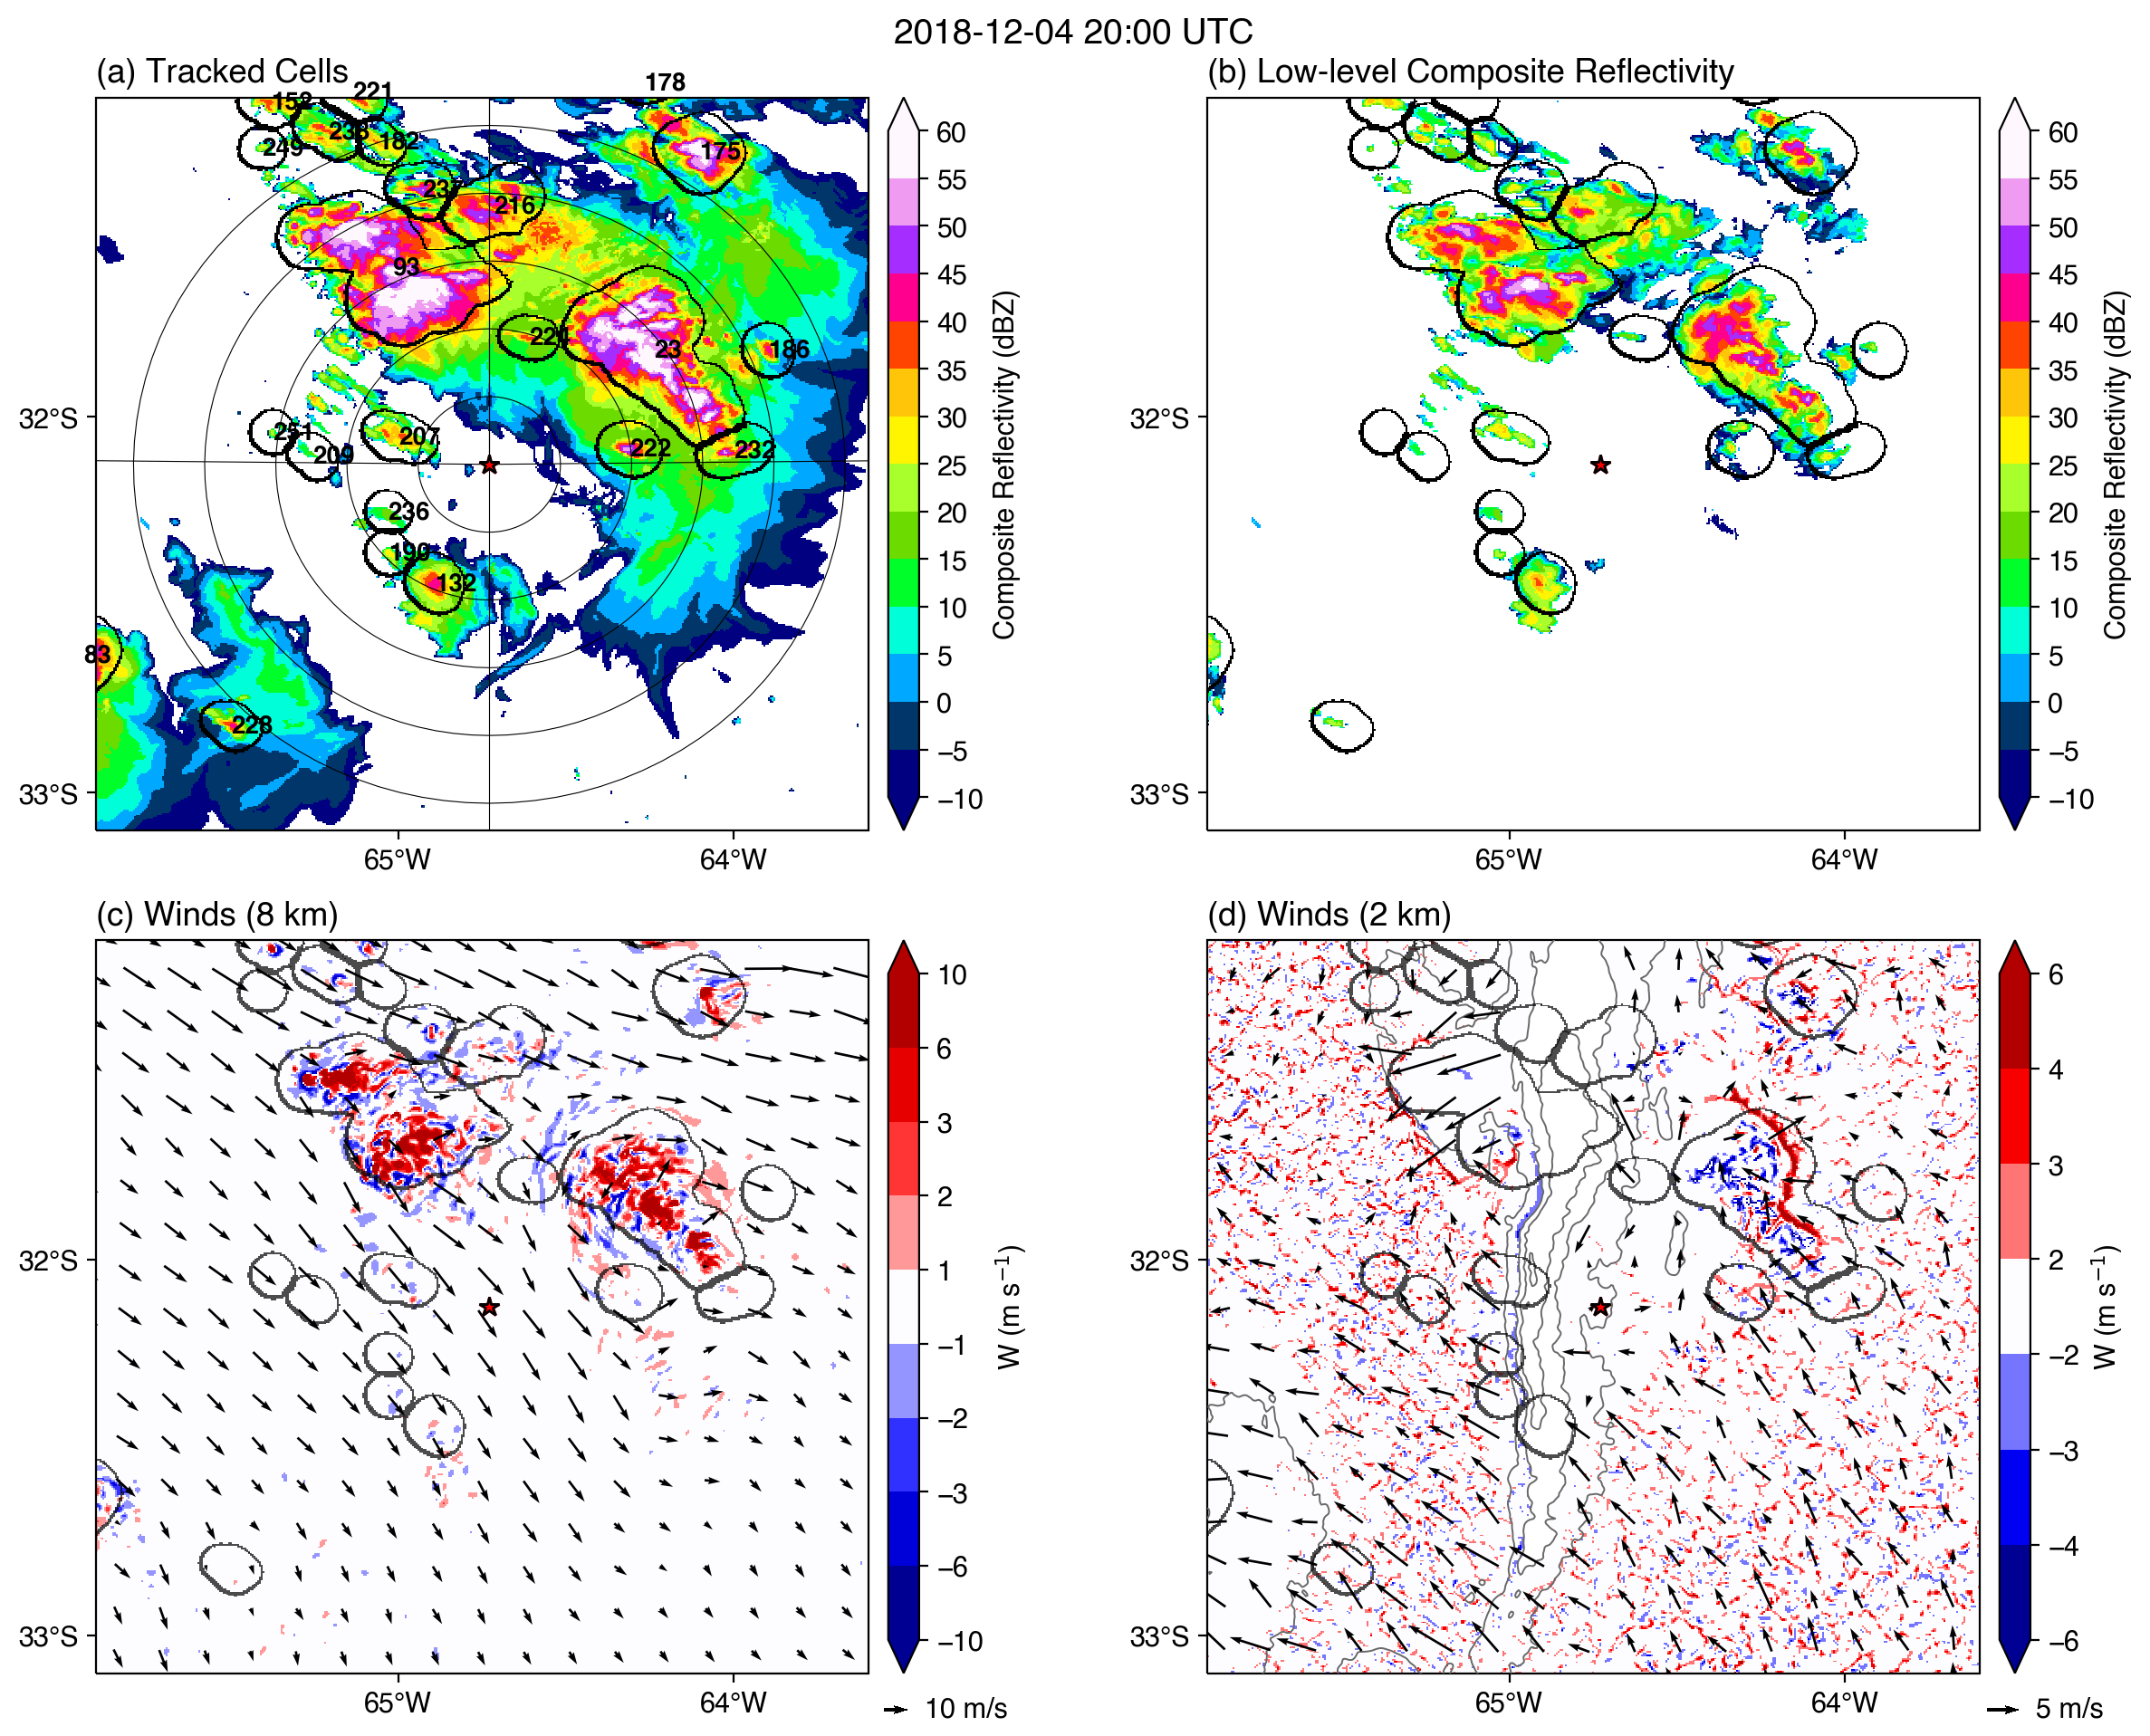

In [17]:
# Make dilation structure (larger values make thicker outlines)
perim_thick = 5
dilationstructure = np.zeros((perim_thick+1,perim_thick+1), dtype=int)
dilationstructure[1:perim_thick, 1:perim_thick] = 1
# dilationstructure = generate_binary_structure(2,1)

# Get cell tracknumbers and cloudnumbers
# cn = ds['feature_number'].squeeze()
tn = ds.tracknumber.squeeze()
cn = ds.cloudnumber.squeeze()
# Only plot if there is cell in the frame
if (np.nanmax(cn) > 0):

    # Subset pixel data within the map domain
    map_extend = map_info['map_extend']
    buffer = 0.05  # buffer area for subset
    lonmin, lonmax = map_extend[0]-buffer, map_extend[1]+buffer
    latmin, latmax = map_extend[2]-buffer, map_extend[3]+buffer
    mask = (ds['longitude'] >= lonmin) & (ds['longitude'] <= lonmax) & (ds['latitude'] >= latmin) & (ds['latitude'] <= latmax)
    xx_sub = mask.where(mask == True, drop=True).lon.data
    yy_sub = mask.where(mask == True, drop=True).lat.data
    xmin = mask.where(mask == True, drop=True).lon.min().item()
    xmax = mask.where(mask == True, drop=True).lon.max().item()
    ymin = mask.where(mask == True, drop=True).lat.min().item()
    ymax = mask.where(mask == True, drop=True).lat.max().item()
    lon_sub = ds['longitude'].isel(lon=slice(xmin,xmax), lat=slice(ymin,ymax)).data
    lat_sub = ds['latitude'].isel(lon=slice(xmin,xmax), lat=slice(ymin,ymax)).data
    terrain = dsmap['HGT'].isel(west_east=slice(xmin,xmax), south_north=slice(ymin,ymax)).squeeze().data
    comp_ref = ds['comp_ref'].isel(lon=slice(xmin,xmax), lat=slice(ymin,ymax)).squeeze()
    lowlevel_ref = ds['dbz_lowlevel'].isel(lon=slice(xmin,xmax), lat=slice(ymin,ymax)).squeeze()
    convmask_sub = ds['conv_mask'].isel(lon=slice(xmin,xmax), lat=slice(ymin,ymax)).squeeze()
    tracknumber_sub = ds['tracknumber'].isel(lon=slice(xmin,xmax), lat=slice(ymin,ymax)).squeeze()
    cloudnumber_sub = ds['cloudnumber'].isel(lon=slice(xmin,xmax), lat=slice(ymin,ymax)).squeeze()
    cn_notrack = cloudnumber_sub.where(np.isnan(tracknumber_sub))
    # Get object perimeters
    tn_perim = label_perimeter(tracknumber_sub.data, dilationstructure)
    cn_perim = label_perimeter(cloudnumber_sub.data, dilationstructure)
    cn_notrack_perim = label_perimeter(cn_notrack.data, dilationstructure)
    # Get met variables
    ht_low = 1500.
    lon_subsample = ds['longitude'].isel(lon=slice(xmin,xmax,vec_subsample), lat=slice(ymin,ymax,vec_subsample)).data
    lat_subsample = ds['latitude'].isel(lon=slice(xmin,xmax,vec_subsample), lat=slice(ymin,ymax,vec_subsample)).data
    u_low = dsm['UA'].sel(HAMSL=ht_low).isel(lon=slice(xmin,xmax,vec_subsample), lat=slice(ymin,ymax,vec_subsample)).squeeze()
    v_low = dsm['VA'].sel(HAMSL=ht_low).isel(lon=slice(xmin,xmax,vec_subsample), lat=slice(ymin,ymax,vec_subsample)).squeeze()
    w_low = dsm['WA'].sel(HAMSL=ht_low).isel(lon=slice(xmin,xmax), lat=slice(ymin,ymax)).squeeze()
    ht_up = 8000.
    u_up = dsm['UA'].sel(HAMSL=ht_up).isel(lon=slice(xmin,xmax,vec_subsample), lat=slice(ymin,ymax,vec_subsample)).squeeze()
    v_up = dsm['VA'].sel(HAMSL=ht_up).isel(lon=slice(xmin,xmax,vec_subsample), lat=slice(ymin,ymax,vec_subsample)).squeeze()
    w_up = dsm['WA'].sel(HAMSL=ht_up).isel(lon=slice(xmin,xmax), lat=slice(ymin,ymax)).squeeze()

    # Apply tracknumber to conv_mask1
    tnconv1 = tracknumber_sub.where(convmask_sub > 0).data

    # Calculates cell center locations
    lon_tn1, lat_tn1, xx_tn1, yy_tn1, tnconv1_unique = calc_cell_center(tnconv1, lon_sub, lat_sub, xx_sub, yy_sub)
    lon_cn1, lat_cn1, xx_cn1, yy_cn1, cnnotrack_unique = calc_cell_center(cn_notrack.data, lon_sub, lat_sub, xx_sub, yy_sub)
    
    levels_ref = np.arange(-10, 60.1, 5)
    cbticks_ref = np.arange(-10, 60.1, 5)
    # levels_w_low = [-4, -2, -1, -0.5, 0.5, 1, 2, 4]
    levels_w_low = [-6, -4, -3, -2, 2, 3, 4, 6]
    levels_w_up = [-10, -6, -3, -2, -1, 1, 2, 3, 6, 10]
    cbticks_w_low = levels_w_low
    cbticks_w_up = levels_w_up
    cmap_ref = 'gist_ncar'
    cmap_w = 'seismic'
    cmap_w = copy.copy(plt.get_cmap(cmap_w))
    cmap_w = truncate_colormap(cmap_w, 0.1, 0.9)
    # titles = ['(a) Tracked Cells', '(b) Not Tracked Cells']
    titles = ['(a) Tracked Cells', '(b) Low-level Composite Reflectivity', f'(c) Winds ({ht_up/1000:.0f} km)', f'(d) Winds ({ht_low/1000:.0f} km)']
    cblabel_ref = 'Composite Reflectivity (dBZ)'
    cblabel_w_low = 'W (m s$^{-1}$)'
    cblabel_w_up = 'W (m s$^{-1}$)'
    timestr = ds.time.squeeze().dt.strftime("%Y-%m-%d %H:%M UTC").data
    fignametimestr = ds.time.squeeze().dt.strftime("%Y%m%d_%H%M").data.item()
    figbase = 'celltrack_winds_'
    figname =  f'{figdir}{figbase}{fignametimestr}.png'

    pixel_dict = {
        'longitude': lon_sub, 
        'latitude': lat_sub, 
        'terrain': terrain,
        'comp_ref': comp_ref,
        'lowlevel_ref': lowlevel_ref,
        'tn': tracknumber_sub,
        'conv_mask': convmask_sub,
        'tn_perim': tn_perim, 
        'cn_notrack_perim': cn_notrack_perim, 
        'lon_tn1': lon_tn1, 
        'lat_tn1': lat_tn1, 
        'tnconv1_unique': tnconv1_unique, 
        'lon_cn1': lon_cn1, 
        'lat_cn1': lat_cn1, 
        'cnnotrack_unique': cnnotrack_unique, 
        'lon_subsample': lon_subsample,
        'lat_subsample': lat_subsample,
        'u_low': u_low,
        'v_low': v_low,
        'w_low': w_low,
        'u_up': u_up,
        'v_up': v_up,
        'w_up': w_up,
    }
    plot_info = {
        'levels_ref': levels_ref, 
        'levels_w_low': levels_w_low,
        'levels_w_up': levels_w_up,
        'cmap_ref': cmap_ref, 
        'cmap_w': cmap_w,        
        'titles': titles, 
        'cblabel_ref': cblabel_ref, 
        'cbticks_ref': cbticks_ref, 
        'cblabel_w_low': cblabel_w_low,
        'cbticks_w_low': cbticks_w_low,
        'cblabel_w_up': cblabel_w_up,
        'cbticks_w_up': cbticks_w_up,
        'timestr': timestr, 
        'figname': figname,
    }
    fig = plot_map_4panels(pixel_dict, plot_info, map_info)
    # plt.close(fig)
    print(figname)